# 데이터 시각화 종합 연습문제


## #01. 데이터 분포


### 문제1

#### kings_life 데이터는 조선시대 역대 왕의 수명을 조사한 데이터이다.수명에 대해 기술통계량을 구하고 상자그림을 그려라. 최종적으로 분석 결과를 토대로 하여 알 수 있는 사실을 하나 이상 제시하라

In [1]:
from hossam import load_data
from matplotlib import font_manager as fm
from matplotlib import pyplot as plt
import seaborn as sb
from pandas import melt, pivot_table
import numpy as np

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data("kings_life")
origin

[data] https://data.hossam.kr/data/lab06/kings_life.xlsx
[desc] 조선시대 역대 왕의 수명을 조사한 데이터 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)
[!] Cannot read metadata


,왕,수명
0,태조,73
1,정종,62
2,태종,45
3,세종,53
4,문종,38
5,단종,16
6,세조,51
7,예종,28
8,성종,37
9,연산,30


In [4]:
# 기술통계량
origin.describe()

,수명
count,27.000000
mean,46.037037
std,16.173296
min,16.000000
25%,33.000000
50%,45.000000
75%,56.000000
max,82.000000


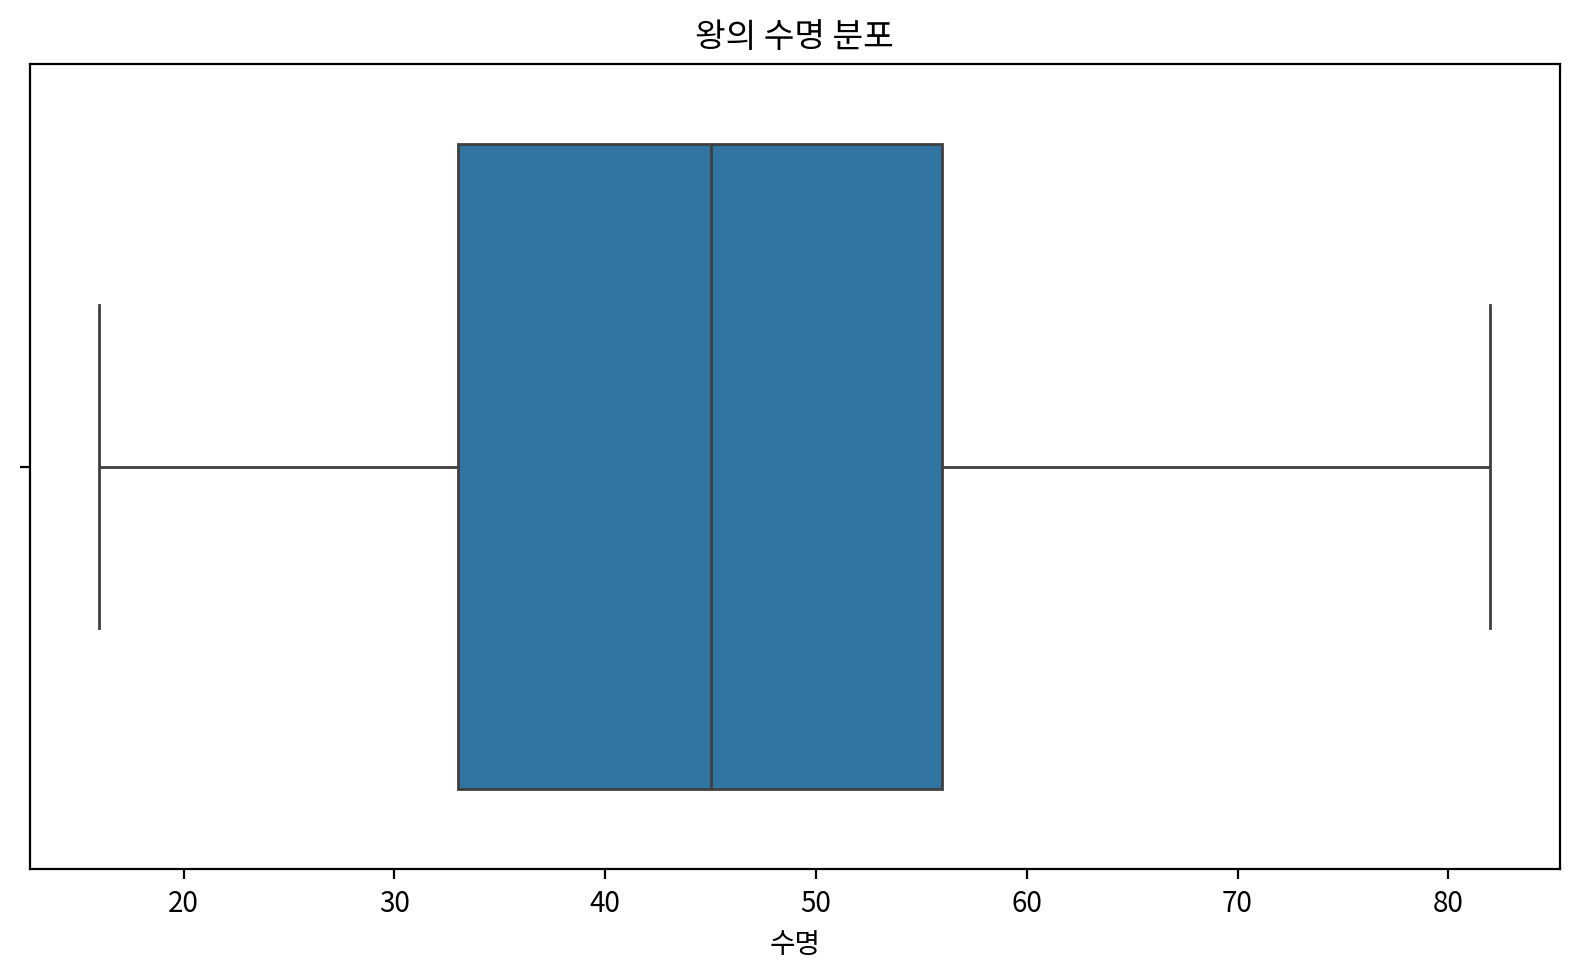

In [5]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1600
height_px = 1000
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.boxplot(data=origin,x='수명')


#ax.grid(True)
ax.set_title('왕의 수명 분포')

plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

기술통계량에 따르면 조선시대 왕들의 수명은 최저 16세, 최고 82세로 나타난다.
상자그림을 보면 왕들의 수명 분포는 대체로 30대 중반에서 50대 중반 구간에 집중되어 있으며, 평균 수명은 약 46세로 나타난다.

### 문제2

#### stock 데이터셋은 상장된 금융사 중 외국기업(F)과 내국기업(K)의 주가 데이터의 일부이다.
외국기업과 내국기업별로 기술통계량을 상자그림을 그려서 비교/분석하라. 최종적으로 분석 결과를 토대로 하여 알 수 있는 사실을 하나 이상 제시하라.


In [6]:
origin = load_data("stock")
origin

[data] https://data.hossam.kr/data/lab06/stock.xlsx
[desc] 상장된 금융사 중 외국기업(F)과 내국기업(K)의 주가 데이터 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)
[!] Cannot read metadata


,구분,주가
0,F,120
1,K,165
2,K,147
3,F,144
4,K,135
5,K,161
6,K,102
7,K,165
8,K,170
9,F,147


In [7]:
origin.info()
df1 = origin.astype({'구분': 'category'})
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구분      24 non-null     object
 1   주가      24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   구분      24 non-null     category
 1   주가      24 non-null     int64   
dtypes: category(1), int64(1)
memory usage: 472.0 bytes


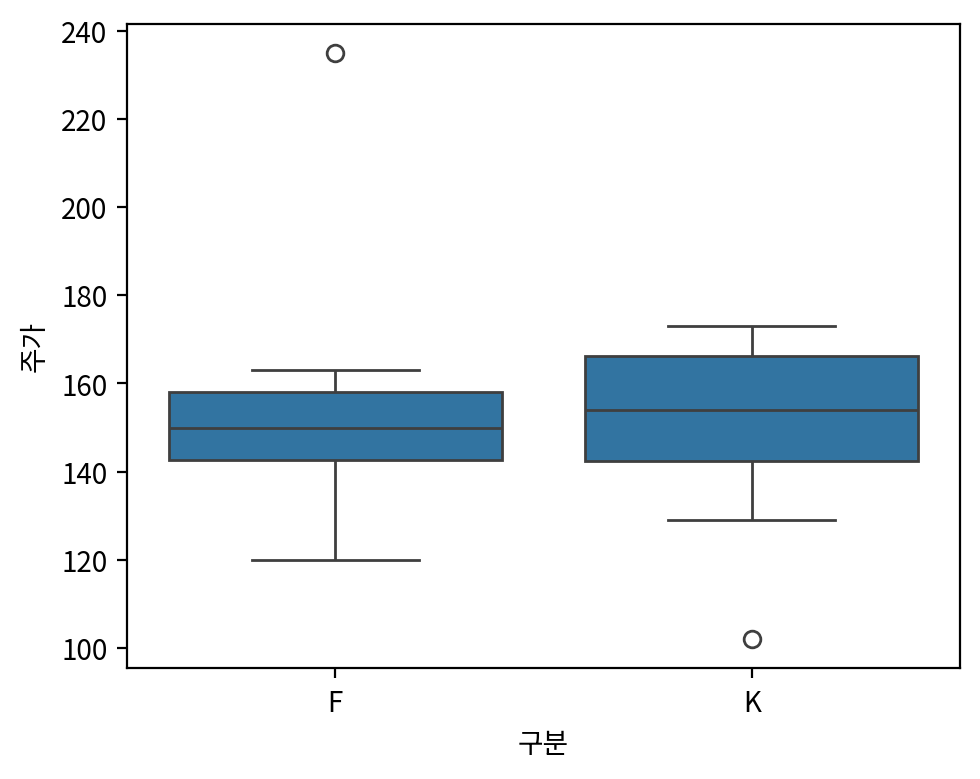

In [8]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.boxplot(data=df1, x='구분', y='주가')

#3) 그래프 꾸미기

# 4) 출력
#plt.grid()
plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

1.'F' 통칭 외국 기업의 주가는 이상치를 제외하면 약 120~160 사이에 분포하며, 사분위수는 약 140~160 사이 구간에 위치하고 중앙값은 약 150 으로 보여진다 또한 약 237 정도의 매우 높은 주가를 가진 이상치가 한 종목 존재하는 것으로 나타난다.    
2.'K' 통칭 국내 기업의 주가는 이상치를 제외하면 약 130~170 구간에 분포하며, 사분위수는 약 140~170 구간에 위치하고 중앙값은 약 155로 외국 기업보다 약간 높은 수준으로 보여지며 약 100 정도의 매우 낮은 주가를 가진 이상치가 한 종목 존재한다.  
3. 따라서 국내 기업은 외국 기업보다 전반적인 주가가 높은 것으로 나타나지만 국내 기업 쪽이 중앙 50%을 기준으로 변동성이 크다는 것을 확인 할 수 있다.

### 문제3

#### grape 데이터셋은 포도농장에서 수집한 비료 종류에 따른 수확량 자료이다.
비료 종류별로 기술통계량을 구하고 상자그림을 그려라. 최종적으로 분석 결과를 토대로 하여 알 수 있는
사실을 하나 이상 제시하라.

In [9]:
origin = load_data("grape")
origin

[data] https://data.hossam.kr/data/lab06/grape.xlsx
[desc] 포도농장에서 수집한 비료 종류에 따른 수확량 자료 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)
[!] Cannot read metadata


,비료종류,수확량
0,A,39.3
1,B,11.4
2,A,26.6
3,A,23.7
4,B,25.8
5,A,28.5
6,A,24.2
7,A,17.9
8,B,16.5
9,B,21.1


In [ ]:
origin.info()
df1 = origin.astype({'비료종류': 'category'})
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   비료종류    11 non-null     object 
 1   수확량     11 non-null     float64
dtypes: float64(1), object(1)
memory usage: 308.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   비료종류    11 non-null     category
 1   수확량     11 non-null     float64 
dtypes: category(1), float64(1)
memory usage: 355.0 bytes


,비료종류,수확량
0,A,39.3
1,B,11.4
2,A,26.6
3,A,23.7
4,B,25.8


In [17]:
df1.groupby('비료종류').describe()

/var/folders/q0/gfh2kgjd38q9q1jlkn069tmr0000gn/T/ipykernel_23540/1168616160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('비료종류').describe()


수확량                                                       
     count       mean       std   min     25%   50%     75%   max
비료종류                                                             
A      7.0  26.357143  6.578211  17.9  23.950  24.3  27.550  39.3
B      4.0  18.700000  6.172520  11.4  15.225  18.8  22.275  25.8

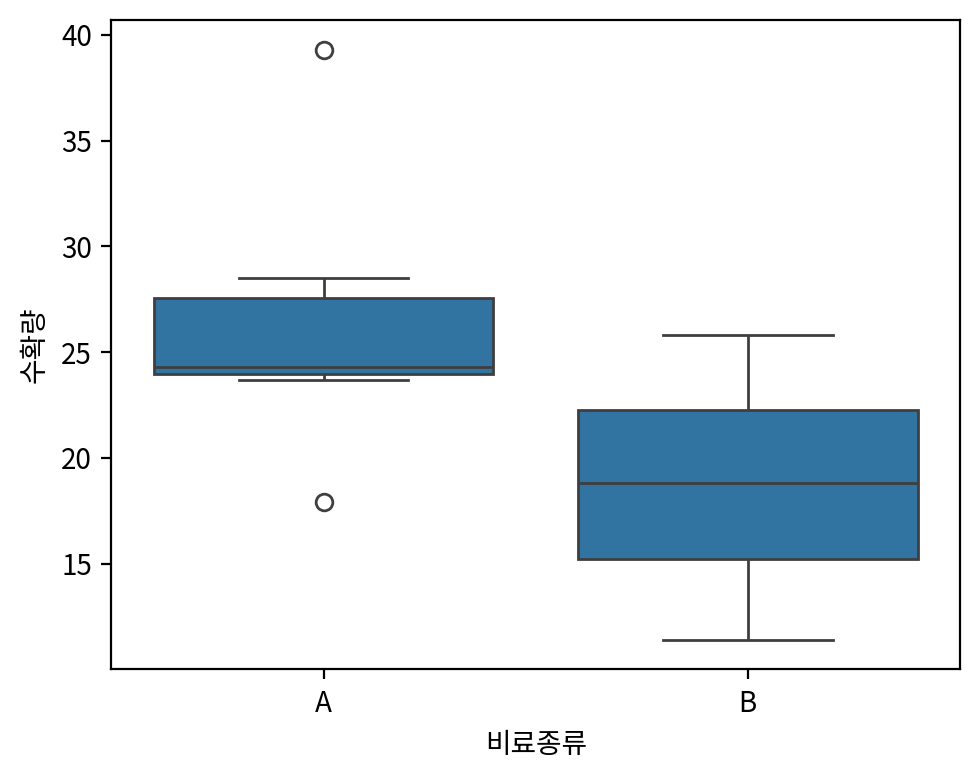

In [11]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.boxplot(data=df1, x='비료종류', y='수확량')

#3) 그래프 꾸미기

# 4) 출력
#plt.grid()
plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

비료 A의 수확량은 이상치를 제외하면 약 18 ~ 40 사이에 분포하며
사분위수는 약 24 ~ 28로 비교적 좁은 범위에 위치한다.
중앙값은 약 24.3으로 나타나며 생산량이 전반적으로 편차가 적은 것으로 나타난다.

비료 B의 수확량은 이상치를 제외하면 약 11 ~ 26 구간에 분포하며
사분위수는 약 15 ~ 22로 A 비료보다 더 낮은 수준에서 형성된다.
중앙값은 약 19로 A 비료보다 확연히 낮아 전반적인 생산량은 B 비료가 더 낮은 것으로 나타난다

A 비료는 일부의 이상치가 존재하는 것으로 보이며, 이에 따라 특정 조건에서 수확량이 불규칙할 것으로 판단된다.